In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv("../data/context_features_dataset.csv")

In [3]:
df.columns = df.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)

In [4]:
if "timestamp" in df.columns:

    df["timestamp"] = pd.to_datetime(df["timestamp"])

    df["hour"] = df["timestamp"].dt.hour
    df["day"] = df["timestamp"].dt.day
    df["month"] = df["timestamp"].dt.month

    df.drop("timestamp", axis=1, inplace=True)

In [5]:
X = df.drop("Machine_failure", axis=1)
y = df["Machine_failure"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [8]:
print(df.columns.tolist())

['UDI', 'Product_ID', 'Type', 'Air_temperature__K_', 'Process_temperature__K_', 'Rotational_speed__rpm_', 'Torque__Nm_', 'Tool_wear__min_', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift', 'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact', 'hour', 'day', 'month']


In [9]:
df.drop(columns=["Product_ID"], inplace=True, errors="ignore")

# If your dataset uses spaces instead of underscores:
df.drop(columns=["Product ID"], inplace=True, errors="ignore")

In [10]:
categorical_cols = ["Type", "Shift", "Day_Type"]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category").cat.codes

In [11]:
print(df.dtypes)

UDI                          int64
Type                          int8
Air_temperature__K_        float64
Process_temperature__K_    float64
Rotational_speed__rpm_       int64
Torque__Nm_                float64
Tool_wear__min_              int64
Machine_failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
Ambient_Temperature          int64
Load_Density                 int64
Humidity                     int64
Shift                         int8
Day_Type                      int8
temp_diff                  float64
load_ratio                 float64
humidity_impact            float64
hour                         int32
day                          int32
month                        int32
dtype: object


In [12]:
X = df.drop("Machine_failure", axis=1)
y = df["Machine_failure"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [14]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001081 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1781
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [Info] Start training from score -3.350616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.999
Precision: 1.0
Recall   : 0.9705882352941176
F1 Score : 0.9850746268656716


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



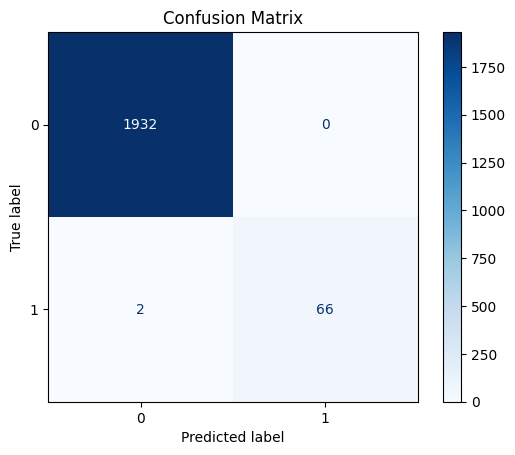

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [19]:
plt.savefig("../reports/confusion_matrix.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [20]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9853397880891488


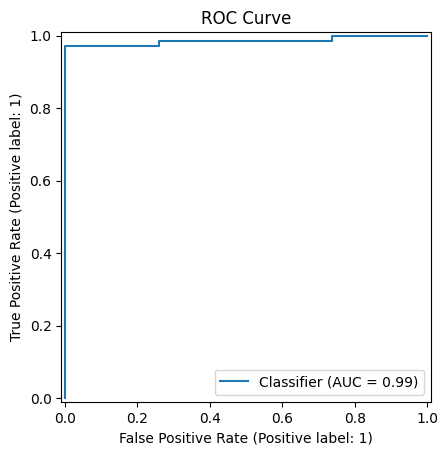

In [21]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve")
plt.show()